# Part 5 (NumPyro-free): Maximum-likelihood estimation via filtering + optax

In the original [Part 5](05_svi.ipynb), we used Stochastic Variational Inference (SVI) to infer parameters by treating the filter-based marginal likelihood as a black-box objective. In this notebook, we replicate the filter-based strand of that workflow **without NumPyro PPL**: since there is no longer a notion of a prior, the natural analog is **maximum-likelihood estimation (MLE)** --- we treat the negative marginal log-likelihood returned by `dsx.condition` as a loss and optimize it directly with [`optax`](https://optax.readthedocs.io/).

The joint state + parameter SVI strand of the original notebook is intrinsically a PPL construction and has no NumPyro-free analog, so it is omitted here; see the original notebook for the Bayesian treatment and that comparison.

### Defining and Sampling From the Model

We return to defining and generating data from our running LTI example.

> **Note:** to keep the data (and hence the figures) identical to the original notebook, this data-generation section reuses the NumPyro-based simulator exactly as in the original. Everything from the inference sections onward is NumPyro-free.

In [1]:
import jax.numpy as jnp
import jax.random as jr
import numpyro
import numpyro.distributions as dist
from numpyro.infer import Predictive

import dynestyx as dsx
from dynestyx import DiscreteTimeSimulator, DynamicalModel

# for convenience, we can define "fixed" things in the model outside of it.
# this is not required, but it helps keep the model clean.
state_dim = 2
observation_dim = 1
control_dim = 1

# Create the known matrices B, C
B = jnp.eye(state_dim, control_dim)
C = jnp.eye(observation_dim, state_dim)

# create the initial condition as a distribution
initial_condition = dist.MultivariateNormal(jnp.zeros(state_dim), jnp.eye(state_dim))


def lti_model(
    sigma_obs=0.1,
    sigma_process=0.1,
    obs_times=None,
    obs_values=None,
    ctrl_times=None,
    ctrl_values=None,
    predict_times=None,
):
    # sample the unknown parameter
    rho = numpyro.sample("rho", dist.Uniform(-0.5, 0.5))
    A = jnp.array([[0, 0.3], [rho, -0.2]])

    # create the state evolution as a callable mapping to a distribution
    # Crucially, this depends on A, which depends on rho, which is unknown.
    # Thus, the state evolution MUST be defined within `lti_model`, not outside.
    state_evolution = lambda x, u, t_now, t_next: dist.MultivariateNormal(
        A @ x + B @ u, sigma_process**2 * jnp.eye(state_dim)
    )

    # create the observation model as a callable mapping to a distribution
    observation_model = lambda x, u, t: dist.MultivariateNormal(
        C @ x, sigma_obs**2 * jnp.eye(observation_dim)
    )

    # create the dynamical model
    dynamics = DynamicalModel(
        control_dim=control_dim,
        initial_condition=initial_condition,
        state_evolution=state_evolution,
        observation_model=observation_model,
    )

    # sample from the dynamical model
    return dsx.sample(
        "f",
        dynamics,
        obs_times=obs_times,
        obs_values=obs_values,
        ctrl_times=ctrl_times,
        ctrl_values=ctrl_values,
        predict_times=predict_times,
    )

In [2]:
# create a synthetic control sequence as i.i.d. Gaussians
obs_times = jnp.arange(0.0, 100.0, 1.0)  # T=100 steps
ctrl_times = obs_times  # same times for controls
ctrl_values = jr.normal(jr.PRNGKey(0), (len(ctrl_times), control_dim))

rho_true = 0.3


def make_data(sigma_obs=0.1, sigma_process=0.1):
    predictive = Predictive(
        lti_model,
        params={"rho": jnp.array(rho_true)},
        num_samples=1,
        exclude_deterministic=False,
    )
    with DiscreteTimeSimulator():
        pred = predictive(
            rng_key=jr.PRNGKey(0),
            sigma_obs=sigma_obs,
            sigma_process=sigma_process,
            predict_times=obs_times,
            ctrl_times=ctrl_times,
            ctrl_values=ctrl_values,
        )
    print("make_data shapes:", pred["f_times"].shape, pred["f_observations"].shape)
    # Expected: f_observations has shape (1, 1, T, obs_dim)
    obs_values = pred["f_observations"][0, 0, :, :]
    return obs_times, obs_values, ctrl_times, ctrl_values


obs_times, obs_values, ctrl_times, ctrl_values = make_data(sigma_obs=0.1, sigma_process=0.1)

make_data shapes: (1, 1, 100) (1, 1, 100, 1)


**Shape convention note:** simulator outputs include a leading `n_simulations` axis (size 1 by default). Under `Predictive`, there is also a leading `num_samples` axis. In this notebook we index those axes explicitly (for example `[0, 0, ...]`) rather than applying generic squeeze helpers.

### Define the dynamics, NumPyro-free

In the original notebook, the unknown parameter $\rho$ was a latent NumPyro sample site with a uniform prior. Without NumPyro there is no notion of a prior: $\rho$ becomes a plain argument, and the model is just a factory returning a `DynamicalModel`.

One further change from the original: the exact (cuthbert) Kalman filter we use below requires the model to be declared in structured linear-Gaussian form --- `LinearGaussianStateEvolution` / `LinearGaussianObservation` rather than anonymous callables --- so we build the same LTI system with the `dsx.LTI_discrete` factory (exactly as dynestyx's own tests do).

In [3]:
def make_dynamics(rho, sigma_obs=0.1, sigma_process=0.1):
    A = jnp.array([[0, 0.3], [rho, -0.2]])
    return dsx.LTI_discrete(
        A=A,
        Q=sigma_process**2 * jnp.eye(state_dim),
        H=C,
        R=sigma_obs**2 * jnp.eye(observation_dim),
        B=B,
        initial_mean=jnp.zeros(state_dim),
        initial_cov=jnp.eye(state_dim),
    )

### Maximum-likelihood estimation of $\rho$ via the filter MLL

We follow the same pattern as the original notebook --- condition the model on data using a filter --- but instead of wrapping it in a NumPyro inference method, we minimize the negative MLL with `optax` (this mirrors the optimization pattern used in dynestyx's own tests, see `tests/test_filter_standalone.py`).

We use the (cuthbert) Kalman filter: for this linear-Gaussian model it computes the marginal likelihood exactly, and its output is differentiable, so we can use plain gradient descent. Stochastic filters (EnKF, PF) can be used the same way, but note that (i) outside a NumPyro seed handler they need an explicit `crn_seed` in their config, and (ii) their MLL estimates are noisy, so the gradients are stochastic.

In [4]:
import jax
import optax

from dynestyx import Filter
from dynestyx.inference.filters import KFConfig


def neg_loglik(rho):
    with Filter(filter_config=KFConfig(filter_source="cuthbert")):
        result = dsx.condition(
            "f",
            make_dynamics(rho),
            obs_times=obs_times,
            obs_values=obs_values,
            ctrl_times=ctrl_times,
            ctrl_values=ctrl_values,
        )
    return -result.marginal_loglik


num_steps = 300
optimizer = optax.adam(learning_rate=1e-2)
rho_hat = jnp.array(0.0)
opt_state = optimizer.init(rho_hat)
loss_and_grad = jax.jit(jax.value_and_grad(neg_loglik))

loss_history, rho_history = [], []
for _ in range(num_steps):
    loss, grad = loss_and_grad(rho_hat)
    updates, opt_state = optimizer.update(grad, opt_state)
    rho_hat = optax.apply_updates(rho_hat, updates)
    loss_history.append(loss)
    rho_history.append(rho_hat)

loss_history = jnp.stack(loss_history)
rho_history = jnp.stack(rho_history)
print(f"MLE estimate: rho_hat = {rho_history[-1]:.4f} (true value {rho_true})")

MLE estimate: rho_hat = 0.3349 (true value 0.3)


### How did the optimization do?

In place of the original notebook's posterior plots over $\rho$, we plot the optimization trace: the loss and the running estimate $\hat{\rho}$, which should converge to a value near $\rho_{\mathrm{true}} = 0.3$.

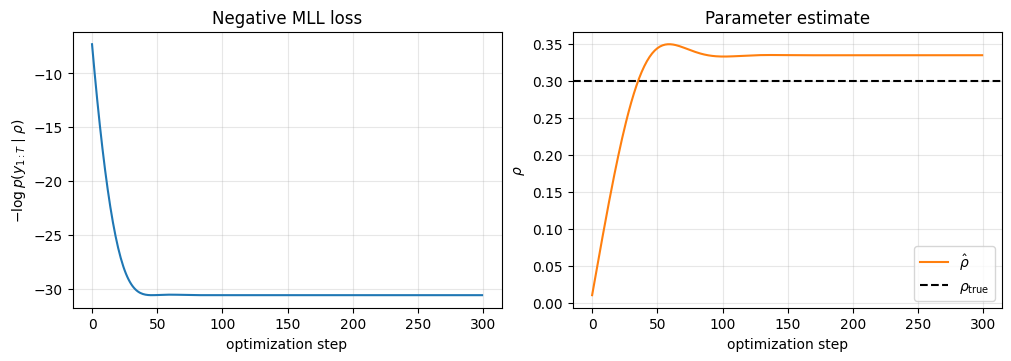

In [5]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(10, 3.5), constrained_layout=True)
axes[0].plot(loss_history, color="C0")
axes[0].set_xlabel("optimization step")
axes[0].set_ylabel(r"$-\log p(y_{1:T} \mid \rho)$")
axes[0].set_title("Negative MLL loss")
axes[0].grid(True, alpha=0.3)
axes[1].plot(rho_history, color="C1", label=r"$\hat{\rho}$")
axes[1].axhline(rho_true, color="k", linestyle="--", label=r"$\rho_{\mathrm{true}}$")
axes[1].set_xlabel("optimization step")
axes[1].set_ylabel(r"$\rho$")
axes[1].set_title("Parameter estimate")
axes[1].legend()
axes[1].grid(True, alpha=0.3)
plt.show()

### Latent-state recovery

As in the original notebook, we can also recover the latent states. Here, we rerun the filter at the MLE $\hat{\rho}$ and read the filtered state distributions from the `ConditionedResult`; this corresponds to a "filtering" distribution.

What is "smoothing" and "filtering":
- The filtering distribution at time `t`:
    - $p(x_t \mid y_1, \dots, y_t, u_1, \dots, u_t)$,
    - only uses data up to the present
- The smoothing distribution at time `t`:
    - $p(x_t \mid y_1, \dots, y_T, u_1, \dots, u_T)$
    - uses all available data.

Unlike the original notebook --- where the uncertainty band came from the spread of filtered means across posterior samples of $\rho$ --- here the band is the filter's own 95% credible interval at the single point estimate $\hat{\rho}$.

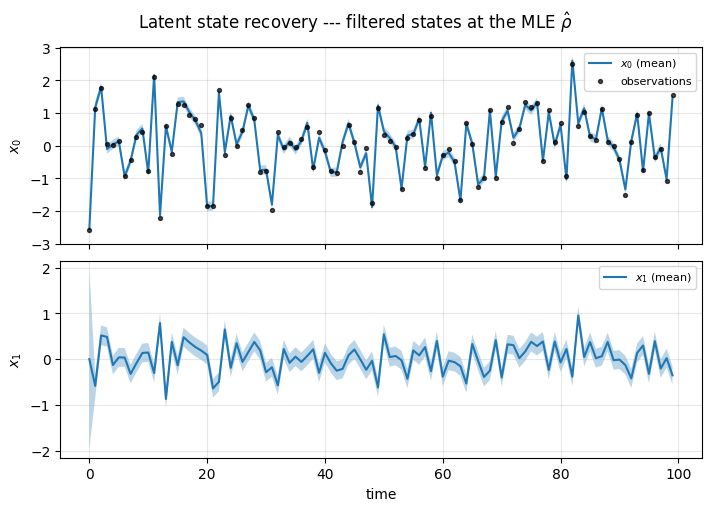

In [6]:
# Rerun the filter at the MLE and read the filtered state distributions.
with Filter(filter_config=KFConfig(filter_source="cuthbert")):
    result = dsx.condition(
        "f",
        make_dynamics(rho_history[-1]),
        obs_times=obs_times,
        obs_values=obs_values,
        ctrl_times=ctrl_times,
        ctrl_values=ctrl_values,
    )

filtered_means = jnp.stack([d.mean for d in result.dists])  # (T, state_dim)
filtered_covs = jnp.stack([d.covariance_matrix for d in result.dists])  # (T, state_dim, state_dim)
filtered_stds = jnp.sqrt(jnp.diagonal(filtered_covs, axis1=1, axis2=2))  # (T, state_dim)

obs_times_np = jnp.asarray(obs_times)
obs_values_np = jnp.asarray(obs_values).squeeze()  # (T,)


def plot_latent_recovery(mean_states, lo, hi, title, obs_times, obs_values, state_dim=2):
    """mean/lo/hi: (T, state_dim). One figure, one subplot per state component."""
    n_comp = state_dim
    fig, axes = plt.subplots(
        n_comp, 1, figsize=(7, 2.5 * n_comp), sharex=True, constrained_layout=True
    )
    if n_comp == 1:
        axes = [axes]
    for i in range(n_comp):
        ax = axes[i]
        ax.fill_between(obs_times_np, lo[:, i], hi[:, i], alpha=0.3)
        ax.plot(obs_times_np, mean_states[:, i], label=f"$x_{i}$ (mean)")
        if i == 0:  # observed component: overlay data
            ax.scatter(
                obs_times_np,
                obs_values_np,
                s=8,
                alpha=0.7,
                color="k",
                label="observations",
                zorder=3,
            )
        ax.set_ylabel(f"$x_{i}$")
        ax.legend(loc="upper right", fontsize=8)
        ax.grid(True, alpha=0.3)
    axes[-1].set_xlabel("time")
    fig.suptitle(title)
    plt.show()


plot_latent_recovery(
    filtered_means,
    filtered_means - 1.96 * filtered_stds,
    filtered_means + 1.96 * filtered_stds,
    r"Latent state recovery --- filtered states at the MLE $\hat{\rho}$",
    obs_times_np,
    obs_values_np,
    state_dim=state_dim,
)

The MLE workflow gives a point estimate of the parameters with state uncertainty from the filter, entirely without NumPyro. For full posterior inference over parameters --- and the comparison with joint state + parameter inference --- see the original NumPyro-based notebooks: [Part 4 (NUTS)](04_filtering_nuts_pseudomarginal.ipynb) and [Part 5 (SVI)](05_svi.ipynb).